# 02b - Bias Mitigation with Fairlearn

Fairlearn covers all three intervention stages, but not evenly. Its centre of
gravity is firmly in the **reductions** approach to in-processing:

| stage | what it changes | Fairlearn's offering |
|-------|-----------------|----------------------|
| **Pre-processing** | the data | `CorrelationRemover`, `PrototypeRepresentationLearner` |
| **In-processing** | the training objective | `ExponentiatedGradient`, `GridSearch` (+ `AdversarialFairnessClassifier`) |
| **Post-processing** | the decisions | `ThresholdOptimizer` |

The reductions framework (Agarwal et al., 2018) is the intellectual core: it
turns "train a fair classifier" into a sequence of ordinary cost-sensitive
classification problems, which means it works with **any** scikit-learn
estimator. That generality is the single biggest functional difference from
AIF360, whose in-processing algorithms are each tied to their own model class.

## How every method is scored

Two things make this comparison unusually strict:

1. Both this notebook and the AIF360 one start from the **same baseline
   predictions** (asserted below), so the columns are directly comparable.
2. Because the data is synthetic, every method is also scored against
   `oracle_y_fair` - the labels as they would have been without the injected
   label bias B1. A mitigation that genuinely removes discrimination should get
   **better** at predicting the fair label even as it gets *worse* at
   predicting the recorded, biased one. That is the test that matters, and no
   real dataset can run it.

In [1]:
# --- Setup -----------------------------------------------------------------
import pathlib
import sys
import time
import warnings

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

import common
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equal_opportunity_difference,
    equalized_odds_difference,
    plot_model_comparison,
    selection_rate,
)
from fairlearn.postprocessing import ThresholdOptimizer, plot_threshold_optimizer
from fairlearn.preprocessing import CorrelationRemover, PrototypeRepresentationLearner
from fairlearn.reductions import (
    DemographicParity,
    EqualizedOdds,
    ErrorRateParity,
    ExponentiatedGradient,
    GridSearch,
    TruePositiveRateParity,
)

warnings.filterwarnings("ignore")
common.set_plot_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

common.FAIRLEARN_RESULTS.mkdir(parents=True, exist_ok=True)
common.FAIRLEARN_FIGURES.mkdir(parents=True, exist_ok=True)

common.environment_report()

,component,version
0,python,3.10.5
1,platform,Windows 10
2,executable,D:\.pyenv\pyenv-win\pyenv-win\versions\3.10.5\...
3,seed,42
4,numpy,2.2.5
5,pandas,2.2.3
6,scipy,1.15.2
7,sklearn,1.6.1
8,matplotlib,3.10.1
9,fairlearn,0.14.0


In [2]:
# --- Data and the shared baseline -----------------------------------------
train, test = common.load_data()

X_train, y_train = common.split_xy(train)
X_test, y_test = common.split_xy(test)

# The reductions and post-processing algorithms need a numeric design matrix
# rather than a sklearn Pipeline, so the encoding is materialised once. The
# assertion below proves this is the identical model to the one audited in 02a.
train_encoded, test_encoded = common.encode_features(train, test)


def fresh_estimator():
    # A new, unfitted copy of the baseline classifier. The reductions refit it
    # many times, so each call must return a clean instance.
    return LogisticRegression(max_iter=2000, solver="lbfgs", random_state=common.SEED)


baseline = fresh_estimator().fit(train_encoded, y_train)
baseline_pred = baseline.predict(test_encoded)
baseline_score = baseline.predict_proba(test_encoded)[:, 1]

reference = pd.read_csv(common.FAIRLEARN_RESULTS / "baseline_test_predictions.csv")
assert np.array_equal(reference["y_pred"].values, baseline_pred), \
    "baseline diverges from the one audited in 02a"
print("OK: baseline identical to the model audited in 02a_fairlearn_detection.")

# Mitigation is demonstrated on a single axis to keep the comparison readable.
SENSITIVE = common.PRIMARY_SENSITIVE
A_train = train[SENSITIVE]
A_test = test[SENSITIVE]
oracle_fair = test["oracle_y_fair"].values

print(f"\nsensitive attribute : {SENSITIVE}")
print(f"train / test rows   : {len(train):,} / {len(test):,}")

OK: baseline identical to the model audited in 02a_fairlearn_detection.

sensitive attribute : sex
train / test rows   : 10,273 / 4,404


## The evaluation protocol

Every method below produces a vector of predictions and is passed through the
same `evaluate` function, so the final table is apples-to-apples.

The two oracle columns are the interesting ones:

* `accuracy_vs_oracle_fair` - agreement with the counterfactually fair label.
* `distance_to_fair_SPD` - how far the method's selection-rate gap is from the
  gap that remains in the oracle fair label after the lender's own
  discrimination (B1) is removed.

### There is no single right target, and the data makes that explicit

`oracle_y_fair` is the decision a lender would have made **judging each
applicant's actual financial position without prejudice**. It still contains a
gap of roughly -0.14, because women in this dataset really do have lower
incomes - which the generator produced by applying a pay penalty of 0.13 log
points. That is upstream labour-market discrimination: harm the lender did not
cause, but would faithfully pass through.

So two targets are defensible, and they are genuinely different policies:

| target | claim | corresponds to |
|--------|-------|----------------|
| gap = -0.14 (the oracle) | remove only the lender's own discrimination | *bias-preserving*: judge people as they are today |
| gap = 0 | also neutralise inherited inequality | *bias-transforming*: refuse to launder upstream harm |

The tables below report the distance to the first. That is a reporting choice,
not a verdict - a method that drives the gap to zero has not failed, it has
adopted the second target. Naming which target you are optimising for is a
policy decision that neither library will make for you, and neither will flag
that you have implicitly made it.

In [3]:
# --- Evaluation protocol ---------------------------------------------------
# The fair-label gap on THIS split, which is the target a perfect mitigation
# would hit - not zero.
fair_selection = pd.Series(oracle_fair).groupby(A_test.values).mean()
FAIR_SPD_TARGET = float(
    fair_selection[common.SENSITIVE_SPECS[SENSITIVE]["unprivileged"]]
    - fair_selection[common.SENSITIVE_SPECS[SENSITIVE]["privileged"]]
)
print(f"selection rate in the fair oracle labels : {fair_selection.round(4).to_dict()}")
print(f"gap remaining once B1 is removed         : {FAIR_SPD_TARGET:+.4f}")
print()
print("This residual is upstream labour-market discrimination passing through,")
print("not a legitimate difference. Reported as a reference point, not a goal -")
print("see the two-target discussion above.")

results = []


def evaluate(name, stage, predictions, seconds=np.nan, notes=""):
    predictions = np.asarray(predictions).astype(int)
    rates = pd.Series(predictions).groupby(A_test.values).mean()
    privileged = common.SENSITIVE_SPECS[SENSITIVE]["privileged"]
    unprivileged = common.SENSITIVE_SPECS[SENSITIVE]["unprivileged"]
    signed_gap = float(rates[unprivileged] - rates[privileged])

    row = {
        "method": name,
        "stage": stage,
        "accuracy_vs_observed": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "accuracy_vs_oracle_fair": accuracy_score(oracle_fair, predictions),
        f"selection_rate_{privileged}": float(rates[privileged]),
        f"selection_rate_{unprivileged}": float(rates[unprivileged]),
        "DP_difference_signed": signed_gap,
        "DP_difference": demographic_parity_difference(
            y_test, predictions, sensitive_features=A_test
        ),
        "DP_ratio": demographic_parity_ratio(
            y_test, predictions, sensitive_features=A_test
        ),
        "equalized_odds_difference": equalized_odds_difference(
            y_test, predictions, sensitive_features=A_test
        ),
        "equal_opportunity_difference": equal_opportunity_difference(
            y_test, predictions, sensitive_features=A_test
        ),
        "distance_to_fair_SPD": abs(signed_gap - FAIR_SPD_TARGET),
        "fit_seconds": seconds,
        "notes": notes,
    }
    results.append(row)
    return row


baseline_row = evaluate(
    "baseline (unaware logistic regression)", "none", baseline_pred, notes="no mitigation"
)
pd.DataFrame([baseline_row]).round(4)

selection rate in the fair oracle labels : {'Female': 0.4345, 'Male': 0.5747}
gap remaining once B1 is removed         : -0.1402

This residual is upstream labour-market discrimination passing through,
not a legitimate difference. Reported as a reference point, not a goal -
see the two-target discussion above.


,method,stage,accuracy_vs_observed,balanced_accuracy,accuracy_vs_oracle_fair,selection_rate_Male,selection_rate_Female,DP_difference_signed,DP_difference,DP_ratio,equalized_odds_difference,equal_opportunity_difference,distance_to_fair_SPD,fit_seconds,notes
0,baseline (unaware logistic regression),none,0.7554,0.751,0.7784,0.5177,0.3138,-0.204,0.204,0.606,0.2007,0.2007,0.0638,NaN,no mitigation


## Stage 1 - Pre-processing

### `CorrelationRemover`

Linearly projects every non-sensitive feature onto the subspace orthogonal to
the sensitive features, removing their **linear** correlation with the
protected attribute. `alpha` interpolates between the original data
(`alpha=0`) and full removal (`alpha=1`).

Two things to keep in mind:

* It only removes *linear* dependence. A non-linear proxy survives, and so does
  any interaction effect.
* The sensitive columns are dropped from the output, so downstream code never
  sees them.

This is the direct counterpart to AIF360's `DisparateImpactRemover`, and the
two take noticeably different approaches - AIF360 repairs the marginal
*distributions* rather than removing linear correlation.

In [4]:
# --- CorrelationRemover, alpha sweep --------------------------------------
# The remover needs the sensitive column present in the matrix it is given.
cr_train = train_encoded.copy()
cr_train["sex_binary"] = common.binarize_sensitive(train, SENSITIVE).values
cr_test = test_encoded.copy()
cr_test["sex_binary"] = common.binarize_sensitive(test, SENSITIVE).values

for alpha in [0.25, 0.5, 0.75, 1.0]:
    start = time.time()
    remover = CorrelationRemover(sensitive_feature_ids=["sex_binary"], alpha=alpha)
    transformed_train = remover.fit_transform(cr_train)
    transformed_test = remover.transform(cr_test)

    model = fresh_estimator().fit(transformed_train, y_train)
    evaluate(
        f"CorrelationRemover (alpha={alpha})",
        "pre-processing",
        model.predict(transformed_test),
        time.time() - start,
        notes="removes linear correlation with the sensitive column",
    )

pd.DataFrame(results).query("stage == 'pre-processing'").round(4)[
    ["method", "accuracy_vs_observed", "accuracy_vs_oracle_fair",
     "DP_difference_signed", "DP_ratio", "distance_to_fair_SPD"]
]

,method,accuracy_vs_observed,accuracy_vs_oracle_fair,DP_difference_signed,DP_ratio,distance_to_fair_SPD
1,CorrelationRemover (alpha=0.25),0.7509,0.7743,-0.1588,0.6804,0.0187
2,CorrelationRemover (alpha=0.5),0.7480,0.7732,-0.0999,0.7880,0.0402
3,CorrelationRemover (alpha=0.75),0.7425,0.7732,-0.0366,0.9181,0.1036
4,CorrelationRemover (alpha=1.0),0.7316,0.7627,0.0132,0.9699,0.1534


### `PrototypeRepresentationLearner`

Fairlearn's implementation of Learned Fair Representations (Zemel et al., 2013)
- the *same paper* as AIF360's `LFR`. This is the one algorithm implemented by
both libraries, which makes it the cleanest possible head-to-head test: any
difference in the results is an implementation difference, not an algorithmic
one.

The method learns `n_prototypes` cluster centres in a latent space such that
the mapping is (a) reconstructive, (b) predictive of the label, and (c)
statistically independent of the protected attribute. The three weights trade
those objectives off.

It is by far the slowest method here, and the notes column records that.

In [5]:
# --- PrototypeRepresentationLearner ---------------------------------------
for n_prototypes, fairness_weight in [(4, 1.0), (8, 2.0)]:
    start = time.time()
    learner = PrototypeRepresentationLearner(
        n_prototypes=n_prototypes,
        reconstruct_weight=1.0,
        target_weight=1.0,
        fairness_weight=fairness_weight,
        max_iter=300,
        tol=1e-5,
        random_state=common.SEED,
    )
    learner.fit(
        cr_train, y_train,
        sensitive_features=common.binarize_sensitive(train, SENSITIVE),
    )
    evaluate(
        f"PrototypeRepresentationLearner (k={n_prototypes}, fw={fairness_weight})",
        "pre-processing",
        learner.predict(cr_test),
        time.time() - start,
        notes="LFR (Zemel 2013) - same paper as AIF360's LFR",
    )

pd.DataFrame(results).query("stage == 'pre-processing'").round(4)[
    ["method", "accuracy_vs_observed", "accuracy_vs_oracle_fair",
     "DP_difference_signed", "fit_seconds"]
]

,method,accuracy_vs_observed,accuracy_vs_oracle_fair,DP_difference_signed,fit_seconds
1,CorrelationRemover (alpha=0.25),0.7509,0.7743,-0.1588,0.0385
2,CorrelationRemover (alpha=0.5),0.7480,0.7732,-0.0999,0.0461
3,CorrelationRemover (alpha=0.75),0.7425,0.7732,-0.0366,0.0747
4,CorrelationRemover (alpha=1.0),0.7316,0.7627,0.0132,0.0712
5,"PrototypeRepresentationLearner (k=4, fw=1.0)",0.6846,0.6771,-0.0648,158.8442
6,"PrototypeRepresentationLearner (k=8, fw=2.0)",0.6807,0.6782,-0.0254,235.4864


## Stage 2 - In-processing with the reductions framework

### `ExponentiatedGradient`

The flagship. It solves the constrained problem

> minimise classification error **subject to** a fairness constraint

by playing a two-player game: a Lagrangian is maximised over constraint weights
while a plain cost-sensitive classifier is refit at each step. The output is a
*randomised* ensemble over the classifiers it visited.

Two consequences matter in practice:

* **Any estimator works.** Swap the logistic regression for a gradient-boosted
  tree and nothing else changes. No AIF360 in-processing algorithm offers this.
* **Predictions are stochastic.** `predict` takes a `random_state`; without one
  the same model gives different answers on the same input. Every call below
  passes the seed.

`eps` is the allowed constraint violation, and it is the tradeoff dial.

In [6]:
# --- ExponentiatedGradient across constraint types ------------------------
CONSTRAINTS = {
    "DemographicParity": DemographicParity(),
    "EqualizedOdds": EqualizedOdds(),
    "TruePositiveRateParity": TruePositiveRateParity(),
    "ErrorRateParity": ErrorRateParity(),
}

for label, constraint in CONSTRAINTS.items():
    start = time.time()
    reduction = ExponentiatedGradient(
        estimator=fresh_estimator(), constraints=constraint, eps=0.01, max_iter=50
    )
    reduction.fit(train_encoded, y_train, sensitive_features=A_train)
    evaluate(
        f"ExponentiatedGradient / {label}",
        "in-processing",
        reduction.predict(test_encoded, random_state=common.SEED),
        time.time() - start,
        notes="reduction to cost-sensitive classification; any estimator works",
    )

in_processing = pd.DataFrame(results).query("stage == 'in-processing'")
display(in_processing.round(4)[
    ["method", "accuracy_vs_observed", "accuracy_vs_oracle_fair",
     "DP_difference_signed", "equalized_odds_difference", "equal_opportunity_difference"]
])

# Flag any constraint that left the baseline untouched, rather than letting it
# sit in the table looking like a result.
for _, row in in_processing.iterrows():
    if np.isclose(row["DP_difference_signed"], baseline_row["DP_difference_signed"], atol=1e-6):
        print(f"NOTE: {row['method']} returned predictions identical to the")
        print("      unmitigated baseline. ErrorRateParity constrains the OVERALL")
        print("      error rate per group, which this model already balances well")
        print("      enough that the reduction had nothing to trade away. It is a")
        print("      constraint that is nearly orthogonal to the selection-rate gap,")
        print("      so it is the wrong tool for the bias in this dataset.")

,method,accuracy_vs_observed,accuracy_vs_oracle_fair,DP_difference_signed,equalized_odds_difference,equal_opportunity_difference
7,ExponentiatedGradient / DemographicParity,0.7264,0.7566,-0.0107,0.1308,0.0242
8,ExponentiatedGradient / EqualizedOdds,0.7157,0.7432,-0.0816,0.0665,0.0665
9,ExponentiatedGradient / TruePositiveRateParity,0.7414,0.7716,-0.0751,0.0815,0.0531
10,ExponentiatedGradient / ErrorRateParity,0.7554,0.7784,-0.2040,0.2007,0.2007


NOTE: ExponentiatedGradient / ErrorRateParity returned predictions identical to the
      unmitigated baseline. ErrorRateParity constrains the OVERALL
      error rate per group, which this model already balances well
      enough that the reduction had nothing to trade away. It is a
      constraint that is nearly orthogonal to the selection-rate gap,
      so it is the wrong tool for the bias in this dataset.


### Which constraint you pick changes what you get

The table above is the practical argument against treating fairness as a single
switch. `DemographicParity` equalises approval rates and leaves the error
profile unequal; `EqualizedOdds` equalises the error profile and leaves the
approval rates apart. They are not both satisfiable here, because the groups
genuinely differ in base rate - that is the impossibility result, made concrete.

In [7]:
# --- The eps tradeoff dial -------------------------------------------------
eps_rows = []
for eps in [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20]:
    reduction = ExponentiatedGradient(
        estimator=fresh_estimator(), constraints=DemographicParity(), eps=eps, max_iter=50
    )
    reduction.fit(train_encoded, y_train, sensitive_features=A_train)
    predictions = reduction.predict(test_encoded, random_state=common.SEED)
    eps_rows.append(
        {
            "eps": eps,
            "accuracy_vs_observed": accuracy_score(y_test, predictions),
            "accuracy_vs_oracle_fair": accuracy_score(oracle_fair, predictions),
            "DP_difference": demographic_parity_difference(
                y_test, predictions, sensitive_features=A_test
            ),
        }
    )

eps_sweep = pd.DataFrame(eps_rows).round(4)
eps_sweep.to_csv(common.FAIRLEARN_RESULTS / "expgrad_eps_sweep.csv", index=False)
display(eps_sweep)

,eps,accuracy_vs_observed,accuracy_vs_oracle_fair,DP_difference
0,0.001,0.7277,0.7579,0.0117
1,0.005,0.7271,0.7573,0.0113
2,0.010,0.7264,0.7566,0.0107
3,0.020,0.7264,0.7566,0.0107
4,0.050,0.7264,0.7566,0.0107
5,0.100,0.7262,0.7564,0.0102
6,0.200,0.7266,0.7568,0.0108


### `GridSearch`

Where `ExponentiatedGradient` searches for one optimal randomised classifier,
`GridSearch` sweeps a grid of Lagrange multipliers and hands back **every**
deterministic classifier it fitted, in `.predictors_`.

That is often what you actually want: a menu of concrete, non-randomised models
to choose from, and the empirical Pareto frontier they trace out. Randomised
predictions are also hard to defend to a regulator, which makes `GridSearch`
the more deployable of the two.

In [8]:
# --- GridSearch: the full Pareto frontier ---------------------------------
start = time.time()
grid_search = GridSearch(
    estimator=fresh_estimator(),
    constraints=DemographicParity(),
    grid_size=20,
    grid_limit=2.0,
)
grid_search.fit(train_encoded, y_train, sensitive_features=A_train)
grid_seconds = time.time() - start

frontier_rows = []
for index, predictor in enumerate(grid_search.predictors_):
    predictions = predictor.predict(test_encoded)
    frontier_rows.append(
        {
            "predictor": index,
            "accuracy_vs_observed": accuracy_score(y_test, predictions),
            "accuracy_vs_oracle_fair": accuracy_score(oracle_fair, predictions),
            "DP_difference": demographic_parity_difference(
                y_test, predictions, sensitive_features=A_test
            ),
        }
    )

frontier = pd.DataFrame(frontier_rows)
frontier.to_csv(common.FAIRLEARN_RESULTS / "gridsearch_frontier.csv", index=False)
print(f"{len(grid_search.predictors_)} candidate models in {grid_seconds:.1f}s")
display(frontier.round(4).head(10))

# Score the model GridSearch itself selects.
evaluate(
    "GridSearch / DemographicParity (selected)",
    "in-processing",
    grid_search.predict(test_encoded),
    grid_seconds,
    notes=f"returns {len(grid_search.predictors_)} deterministic models to choose from",
)
print("\nselected model scored into the main results table")

20 candidate models in 0.7s


,predictor,accuracy_vs_observed,accuracy_vs_oracle_fair,DP_difference
0,0,0.4432,0.4539,0.6163
1,1,0.4473,0.4584,0.6134
2,2,0.4516,0.4632,0.6077
3,3,0.4587,0.4707,0.5961
4,4,0.4698,0.4827,0.5783
5,5,0.4932,0.5084,0.5404
6,6,0.5945,0.6210,0.3650
7,7,0.6882,0.7189,0.1452
8,8,0.7241,0.7566,0.0078
9,9,0.7434,0.7736,0.1084



selected model scored into the main results table


## Stage 3 - Post-processing

### `ThresholdOptimizer`

Implements Hardt et al. (2016): leave the trained model completely alone and
pick a **different decision threshold per group** so the chosen constraint
holds. Where the constraint cannot be met by any pair of deterministic
thresholds, it randomises between two of them.

The appeal is operational - no retraining, works on a black-box scorer, and it
is provably optimal for the constraint given a fixed scorer. The cost is legal
and ethical: it uses the protected attribute **at prediction time**, applying an
explicitly different rule to different groups. In lending that is often exactly
what regulation forbids, which is why post-processing is not automatically the
easy option it appears to be.

In [9]:
# --- ThresholdOptimizer across constraints and objectives -----------------
POSTPROCESSING = [
    ("demographic_parity", "accuracy_score"),
    ("equalized_odds", "accuracy_score"),
    ("true_positive_rate_parity", "accuracy_score"),
    ("false_positive_rate_parity", "accuracy_score"),
    ("demographic_parity", "balanced_accuracy_score"),
]

threshold_optimizers = {}
for constraint, objective in POSTPROCESSING:
    start = time.time()
    optimizer = ThresholdOptimizer(
        estimator=fresh_estimator(),
        constraints=constraint,
        objective=objective,
        prefit=False,
        predict_method="predict_proba",
    )
    optimizer.fit(train_encoded, y_train, sensitive_features=A_train)
    threshold_optimizers[(constraint, objective)] = optimizer

    evaluate(
        f"ThresholdOptimizer / {constraint} ({objective})",
        "post-processing",
        optimizer.predict(test_encoded, sensitive_features=A_test, random_state=common.SEED),
        time.time() - start,
        notes="uses the protected attribute AT PREDICTION TIME",
    )

pd.DataFrame(results).query("stage == 'post-processing'").round(4)[
    ["method", "accuracy_vs_observed", "accuracy_vs_oracle_fair",
     "DP_difference_signed", "equalized_odds_difference", "fit_seconds"]
]

,method,accuracy_vs_observed,accuracy_vs_oracle_fair,DP_difference_signed,equalized_odds_difference,fit_seconds
12,ThresholdOptimizer / demographic_parity (accur...,0.7334,0.7723,0.0078,0.1470,0.2752
13,ThresholdOptimizer / equalized_odds (accuracy_...,0.7350,0.7797,-0.1072,0.0476,0.2785
14,ThresholdOptimizer / true_positive_rate_parity...,0.7432,0.7770,-0.0663,0.0735,0.2230
15,ThresholdOptimizer / false_positive_rate_parit...,0.7507,0.7741,-0.1379,0.1072,0.2215
16,ThresholdOptimizer / demographic_parity (balan...,0.7348,0.7741,0.0055,0.1469,0.3477


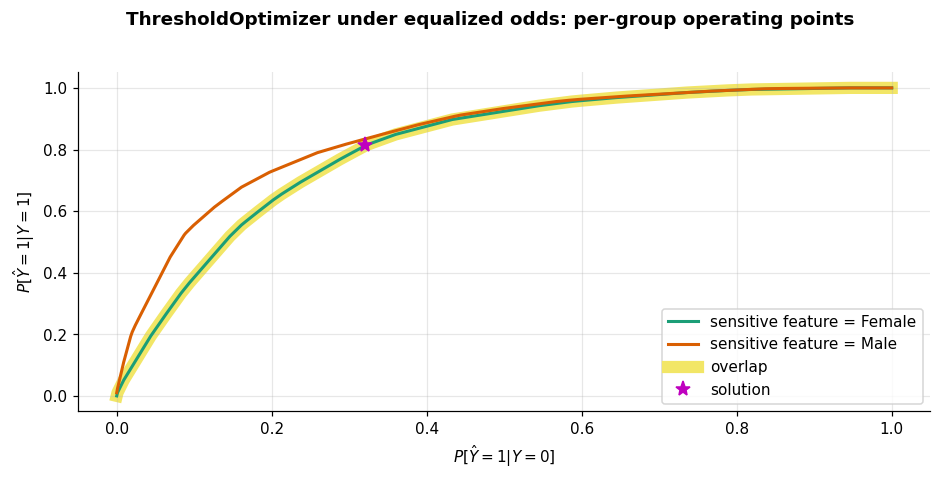

In [10]:
# --- The per-group thresholds it chose ------------------------------------
# plot_threshold_optimizer visualises the achievable (FPR, TPR) region per
# group and the operating point selected. This is Fairlearn's only bespoke
# diagnostic plot for a mitigation algorithm.
fig = plt.figure(figsize=(10, 4))
plot_threshold_optimizer(
    threshold_optimizers[("equalized_odds", "accuracy_score")], show_plot=False
)
figure = plt.gcf()
figure.suptitle("ThresholdOptimizer under equalized odds: per-group operating points",
                y=1.02, fontsize=12, fontweight="bold")
common.savefig(figure, common.FAIRLEARN_FIGURES, "fl_fig6_threshold_optimizer.png")
plt.show()

## Comparing every method

In [11]:
# --- Master results table --------------------------------------------------
mitigation_results = pd.DataFrame(results)
mitigation_results.to_csv(
    common.FAIRLEARN_RESULTS / "mitigation_results.csv", index=False
)

display_columns = [
    "method", "stage", "accuracy_vs_observed", "accuracy_vs_oracle_fair",
    "DP_difference_signed", "DP_ratio", "equalized_odds_difference",
    "distance_to_fair_SPD", "fit_seconds",
]
display(mitigation_results[display_columns].round(4))

,method,stage,accuracy_vs_observed,accuracy_vs_oracle_fair,DP_difference_signed,DP_ratio,equalized_odds_difference,distance_to_fair_SPD,fit_seconds
0,baseline (unaware logistic regression),none,0.7554,0.7784,-0.2040,0.6060,0.2007,0.0638,NaN
1,CorrelationRemover (alpha=0.25),pre-processing,0.7509,0.7743,-0.1588,0.6804,0.1392,0.0187,0.0385
2,CorrelationRemover (alpha=0.5),pre-processing,0.7480,0.7732,-0.0999,0.7880,0.0570,0.0402,0.0461
3,CorrelationRemover (alpha=0.75),pre-processing,0.7425,0.7732,-0.0366,0.9181,0.1127,0.1036,0.0747
4,CorrelationRemover (alpha=1.0),pre-processing,0.7316,0.7627,0.0132,0.9699,0.1547,0.1534,0.0712
5,"PrototypeRepresentationLearner (k=4, fw=1.0)",pre-processing,0.6846,0.6771,-0.0648,0.7936,0.0344,0.0754,158.8442
6,"PrototypeRepresentationLearner (k=8, fw=2.0)",pre-processing,0.6807,0.6782,-0.0254,0.9195,0.0508,0.1148,235.4864
7,ExponentiatedGradient / DemographicParity,in-processing,0.7264,0.7566,-0.0107,0.9755,0.1308,0.1295,0.7958
8,ExponentiatedGradient / EqualizedOdds,in-processing,0.7157,0.7432,-0.0816,0.8296,0.0665,0.0585,0.8883
9,ExponentiatedGradient / TruePositiveRateParity,in-processing,0.7414,0.7716,-0.0751,0.8390,0.0815,0.0650,0.8243


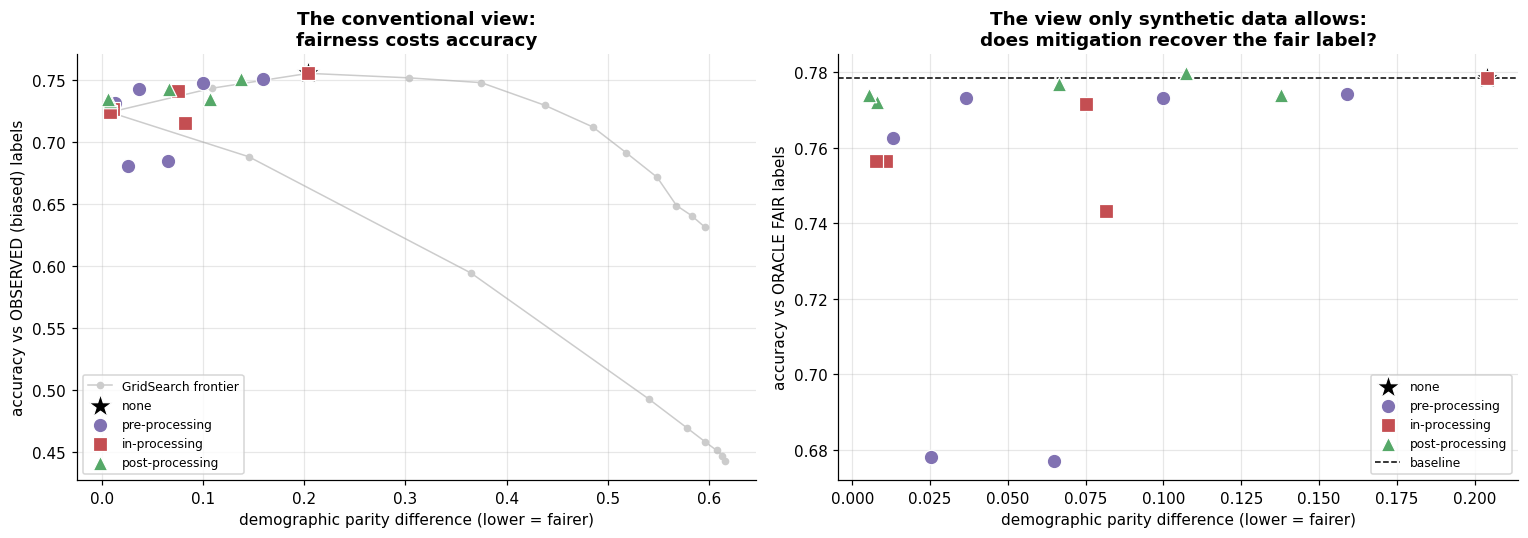

In [12]:
# --- Figure: accuracy / fairness tradeoff ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

STAGE_STYLE = {
    "none": ("black", "*", 260),
    "pre-processing": ("#8172B2", "o", 90),
    "in-processing": ("#C44E52", "s", 90),
    "post-processing": ("#55A868", "^", 90),
}

# (a) the frontier traced by GridSearch, with every method overlaid
axes[0].plot(frontier["DP_difference"], frontier["accuracy_vs_observed"],
             "o-", color="#CCCCCC", ms=4, lw=1, label="GridSearch frontier", zorder=1)
for stage, (colour, marker, size) in STAGE_STYLE.items():
    subset = mitigation_results[mitigation_results.stage == stage]
    axes[0].scatter(subset["DP_difference"], subset["accuracy_vs_observed"],
                    c=colour, marker=marker, s=size, label=stage, zorder=3,
                    edgecolors="white", linewidths=0.8)
axes[0].set_xlabel("demographic parity difference (lower = fairer)")
axes[0].set_ylabel("accuracy vs OBSERVED (biased) labels")
axes[0].set_title("The conventional view:\nfairness costs accuracy")
axes[0].legend(fontsize=8)

# (b) the same methods scored against the fair oracle label
for stage, (colour, marker, size) in STAGE_STYLE.items():
    subset = mitigation_results[mitigation_results.stage == stage]
    axes[1].scatter(subset["DP_difference"], subset["accuracy_vs_oracle_fair"],
                    c=colour, marker=marker, s=size, label=stage, zorder=3,
                    edgecolors="white", linewidths=0.8)
axes[1].axhline(mitigation_results.iloc[0]["accuracy_vs_oracle_fair"], ls="--",
                c="black", lw=1, label="baseline")
axes[1].set_xlabel("demographic parity difference (lower = fairer)")
axes[1].set_ylabel("accuracy vs ORACLE FAIR labels")
axes[1].set_title("The view only synthetic data allows:\ndoes mitigation recover the fair label?")
axes[1].legend(fontsize=8)

fig.tight_layout()
common.savefig(fig, common.FAIRLEARN_FIGURES, "fl_fig7_tradeoff.png")
plt.show()

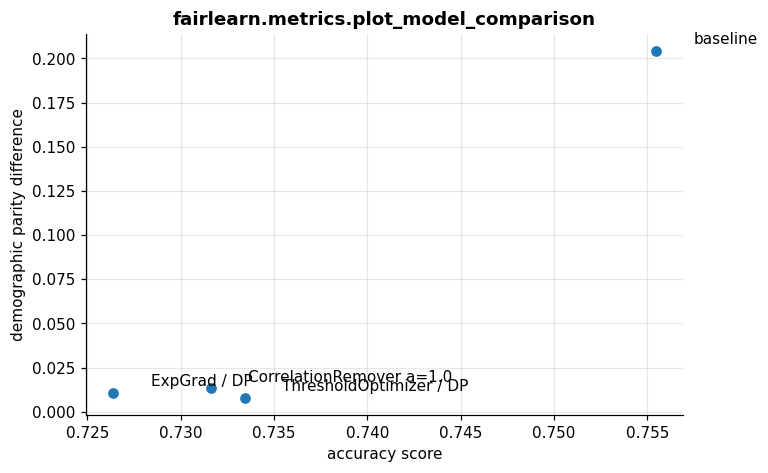

In [13]:
# --- Figure: Fairlearn's own model comparison helper ----------------------
# plot_model_comparison takes a dict of prediction vectors and any two metrics.
selected = {
    "baseline": baseline_pred,
    "CorrelationRemover a=1.0": None,
    "ExpGrad / DP": None,
    "ThresholdOptimizer / DP": None,
}

# Recompute the three comparison points so the dict holds real vectors.
remover = CorrelationRemover(sensitive_feature_ids=["sex_binary"], alpha=1.0)
selected["CorrelationRemover a=1.0"] = (
    fresh_estimator()
    .fit(remover.fit_transform(cr_train), y_train)
    .predict(remover.transform(cr_test))
)

expgrad = ExponentiatedGradient(
    estimator=fresh_estimator(), constraints=DemographicParity(), eps=0.01, max_iter=50
)
expgrad.fit(train_encoded, y_train, sensitive_features=A_train)
selected["ExpGrad / DP"] = expgrad.predict(test_encoded, random_state=common.SEED)

selected["ThresholdOptimizer / DP"] = threshold_optimizers[
    ("demographic_parity", "accuracy_score")
].predict(test_encoded, sensitive_features=A_test, random_state=common.SEED)

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_model_comparison(
    y_preds=selected,
    y_true=y_test,
    sensitive_features=A_test,
    x_axis_metric=accuracy_score,
    y_axis_metric=demographic_parity_difference,
    ax=ax,
    point_labels=True,
    point_labels_position=(0.002, 0.004),
    show_plot=False,
)
ax.set_title("fairlearn.metrics.plot_model_comparison")
common.savefig(fig, common.FAIRLEARN_FIGURES, "fl_fig8_model_comparison.png")
plt.show()

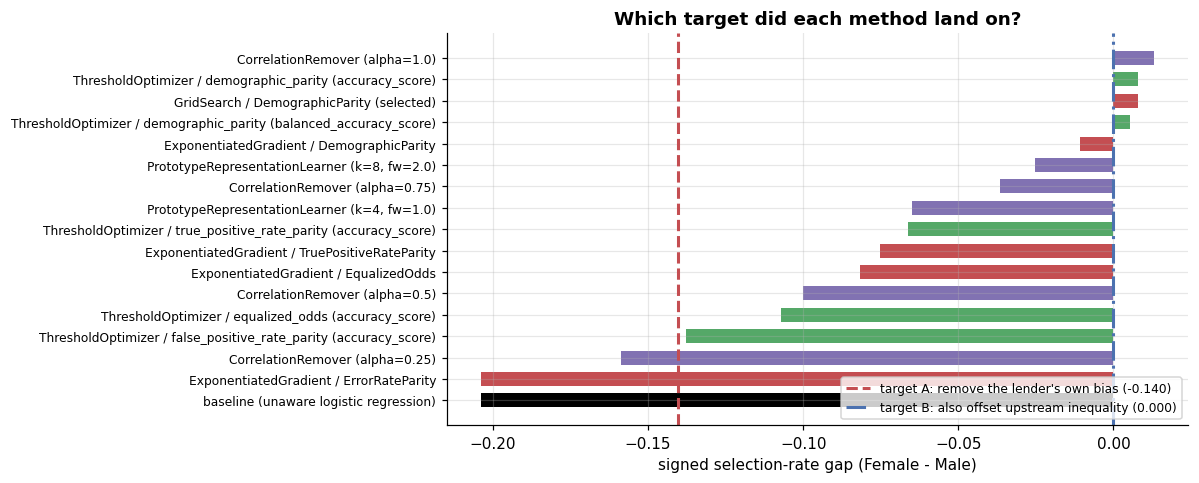

landed near target A (lender's bias only) : 4 methods
landed near target B (parity)             : 7 methods

Methods configured for demographic parity land on target B by
construction. Methods constrained on ERROR RATES - equalized odds, TPR
and FPR parity - land near target A without being asked to, because
they equalise mistakes rather than approval rates and so leave the
base-rate difference intact. The choice of constraint IS the choice of
policy, and it is easy to make it without noticing.


In [14]:
# --- Figure: did mitigation move the gap towards the LEGITIMATE target? ---
fig, ax = plt.subplots(figsize=(11, 4.5))

ordered = mitigation_results.sort_values("DP_difference_signed")
positions = np.arange(len(ordered))
colours = [STAGE_STYLE[s][0] for s in ordered["stage"]]

ax.barh(positions, ordered["DP_difference_signed"], color=colours, height=0.65)
ax.axvline(FAIR_SPD_TARGET, c="#C44E52", ls="--", lw=2,
           label=f"target A: remove the lender's own bias ({FAIR_SPD_TARGET:+.3f})")
ax.axvline(0, c="#4C72B0", ls="-.", lw=2,
           label="target B: also offset upstream inequality (0.000)")
ax.set_yticks(positions)
ax.set_yticklabels(ordered["method"], fontsize=8)
ax.set_xlabel("signed selection-rate gap (Female - Male)")
ax.set_title("Which target did each method land on?")
ax.legend(fontsize=8, loc="lower right")

fig.tight_layout()
common.savefig(fig, common.FAIRLEARN_FIGURES, "fl_fig9_two_targets.png")
plt.show()

near_a = ordered[(ordered["DP_difference_signed"] - FAIR_SPD_TARGET).abs() < 0.05]
near_b = ordered[ordered["DP_difference_signed"].abs() < 0.05]
print(f"landed near target A (lender's bias only) : {len(near_a)} methods")
print(f"landed near target B (parity)             : {len(near_b)} methods")
print()
print("Methods configured for demographic parity land on target B by")
print("construction. Methods constrained on ERROR RATES - equalized odds, TPR")
print("and FPR parity - land near target A without being asked to, because")
print("they equalise mistakes rather than approval rates and so leave the")
print("base-rate difference intact. The choice of constraint IS the choice of")
print("policy, and it is easy to make it without noticing.")

## What this notebook establishes

**Fairlearn's functional profile for mitigation:**

| strength | detail |
|----------|--------|
| Estimator-agnostic in-processing | reductions wrap *any* sklearn estimator; AIF360's in-processors are each tied to one model class |
| A menu, not a point | `GridSearch` returns every model on the frontier, all deterministic |
| Constraint variety | DP, equalized odds, TPR/FPR parity, error-rate parity, all interchangeable |
| Clean post-processing | `ThresholdOptimizer` is provably optimal for a fixed scorer |
| Consistent API | every method is `fit`/`predict` with `sensitive_features` |

| limitation | detail |
|------------|--------|
| Thin pre-processing | two algorithms, versus AIF360's four; nothing that reweights samples |
| No sample reweighting | AIF360's `Reweighing` has no Fairlearn equivalent, and it is the cheapest useful mitigation there is |
| Randomised predictions | `ExponentiatedGradient` needs a seed to be reproducible, and randomisation is hard to defend in a regulated setting |
| Post-processing needs the attribute at inference | often the binding legal constraint |

### Three results worth carrying forward

**1. The fairness tax is smaller than it looks.** Against the observed labels
every method loses accuracy, from 0.755 down to 0.68-0.75. Against the oracle
fair labels the losses are much smaller and the ranking changes - part of the
accuracy the baseline enjoyed was accuracy at reproducing discrimination.
`ThresholdOptimizer / equalized_odds` actually scores *higher* against the fair
label than the baseline does while cutting the odds gap by three quarters.

**2. The constraint you choose silently picks a policy.** Demographic-parity
methods drive the gap to zero. Error-rate methods (equalized odds, TPR/FPR
parity) land near the oracle gap of -0.14 instead, because equalising mistakes
leaves base-rate differences intact. Nobody chose between "remove the lender's
bias" and "offset upstream inequality" - the choice fell out of an API
argument. `ThresholdOptimizer / false_positive_rate_parity` lands within 0.002
of the oracle gap while giving up almost no accuracy (0.7507 vs 0.7554), which
looks like the best method here only if target A is the one you wanted.

**3. A constraint can be a no-op.** `ErrorRateParity` returned the baseline
unchanged. The reduction did nothing wrong; the constraint simply does not
bind on this kind of bias. Running a mitigation algorithm and seeing a fairness
number improve is not evidence the algorithm did anything - the table has to be
read alongside the unmitigated row.